In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

import aymansigmri as asm

import sys
sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")
import riesling as rl

kspace = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coords = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp = kspace, coord=coords, n_missing=0, undersampling_factor=1)

## Setting up linops
1. Estim sensitivity maps ->> use Nufft.H on data then ESPIRIT Calib
2. Take coil images into cartesian kspace to feed into espirit calib
3. Build sensitivy linop with image shape and sensitivity maps
4. Chain F and S together into A

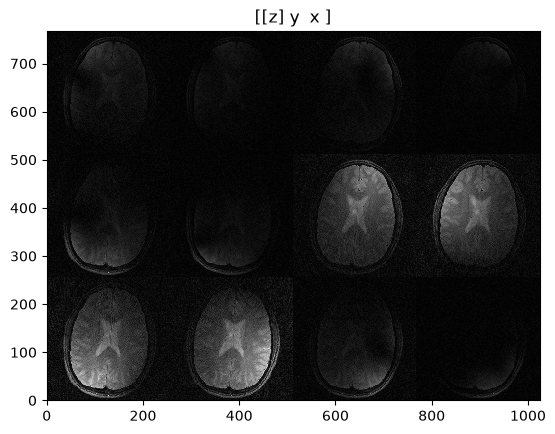

EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

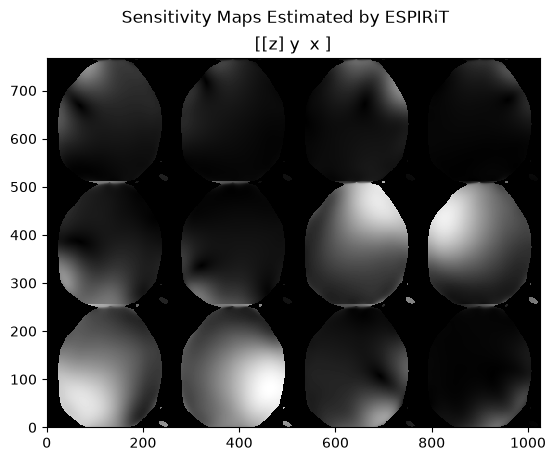

In [2]:
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)

F = sp.linop.NUFFT(ishape=(12,256,256), coord=zte_radial_coords, oversamp=2, width=4)
coil_imgs = F.H * (zte_radial_kspace * dcf)
pl.ImagePlot(coil_imgs, z=0)


ksp_cart = sp.fft(coil_imgs, axes=(-2, -1))
mps = mr.app.EspiritCalib(ksp_cart).run()
pl.ImagePlot(mps, z=0, title='Sensitivity Maps Estimated by ESPIRiT') ##match above coil plot pretty well
S = sp.linop.Multiply((256, 256), mps)

A = F * S

In [3]:
from pathlib import Path
import h5py
import numpy as np
print("mps shape:", mps.shape)
print("mps dtype:", mps.dtype)

maps = mps.astype(np.complex64)

if maps.ndim == 3:
    maps_riesling = maps[:, None, None, :, :]

else:
    raise ValueError(f"Unexpected mps shape: {maps.shape}")

print("Riesling maps shape:", maps_riesling.shape)

mps shape: (12, 256, 256)
mps dtype: complex128
Riesling maps shape: (12, 1, 1, 256, 256)


In [ ]:
'''data_dir = "/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/rrsg"
radial_stem = 'rrsg-radial'
rpre=f'{data_dir}/{radial_stem}'

sense_file = Path(f"{rpre}-sigpy-sense.h5")
sense_file.parent.mkdir(parents=True, exist_ok=True)

with h5py.File(sense_file, "w") as f:
    d = f.create_dataset("data", data=maps_riesling)
    d.attrs["DIMENSION_LABELS"] = np.array(
        ["channel", "b", "k", "j", "i"],
        dtype=h5py.string_dtype(encoding="utf-8")
    )

print("saved:", sense_file.resolve())
print("shape:", maps_riesling.shape)'''

saved: /Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/rrsg/rrsg-radial-sigpy-sense.h5
shape: (12, 1, 1, 256, 256)


### Preconditioner - using `kspace_precond`
- tried to turn this into a linop with same shape as F

NOTE: works with `circulant_precond` although image not looking great

In [18]:
Precond = mr.kspace_precond(mps=mps, weights=None, coord=zte_radial_coords, lamda=0)
Precond_op = sp.linop.Multiply(F.oshape, Precond)
cprecond = mr.circulant_precond(mps=mps, weights=None, coord=zte_radial_coords,lamda=0)
cprecond_op = sp.linop.Multiply((256,256), cprecond)

In [5]:
cprecond.shape

(256, 256)

### Few different solvers, all produce same result
- all except CG run MaxEig first - approx 18 seconds

In [10]:
## lamda is same as sigpy tutorial NOTE: Cell currently not working 10/07 730pm - shape mismatch

lamda = 0.005
y = zte_radial_kspace


prox = sp.prox.L2Reg((256, 256), lamda) 
app = sp.app.LinearLeastSquares(A, y, proxg=prox, max_iter=40, lamda=lamda)
recon = app.run()

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

LinearLeastSquares:   0%|          | 0/40 [00:00<?, ?it/s]

Can't use `proxg = sp.prox.L2Reg((256, 256), lamda)` with conjugate gradient method


1. __FIX PRECONDITIONER__ (Update: works with cprecond although image not looking great)
2. Check kspace values on fft of recon (think still scaling problems as F linop used sigpy NUFFT)

In [29]:
app = sp.app.LinearLeastSquares(A, y,solver="ConjugateGradient",max_iter=15,lamda=lamda, P=cprecond_op)
recon = app.run()

LinearLeastSquares:   0%|          | 0/15 [00:00<?, ?it/s]

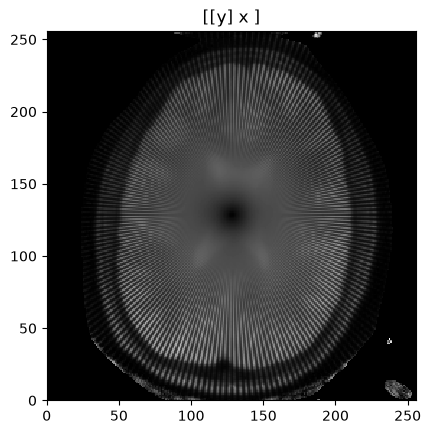

In [30]:
pl.ImagePlot(recon)

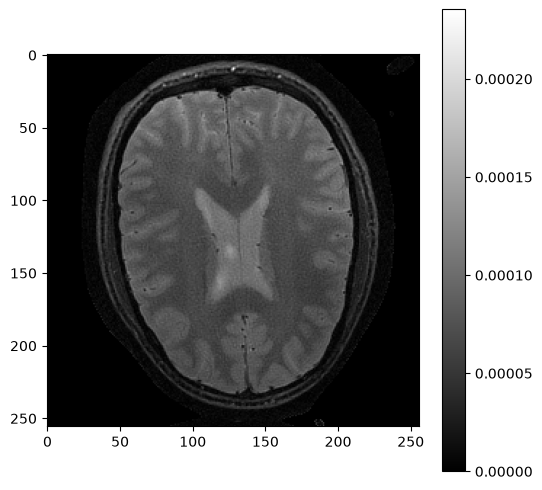

In [14]:
im_rss_cart = np.sum(np.abs(recon)**2, axis=0)**0.5

plt.figure(figsize=(6, 6))
plt.imshow(np.abs(recon), cmap='gray')
plt.colorbar()
plt.show()

In [31]:
from scipy.sparse.linalg import lsmr, LinearOperator

kprecond = mr.kspace_precond(mps, coord=zte_radial_coords)   # shape == A.oshape
w = np.sqrt(kprecond).astype(np.complex64)

def mv(x):
    return (w * (A * x.reshape(A.ishape))).ravel()

def rmv(yy):
    return (A.H * (np.conj(w) * yy.reshape(A.oshape))).ravel()

Aop = LinearOperator(
    shape=(int(np.prod(A.oshape)), int(np.prod(A.ishape))),
    matvec=mv, rmatvec=rmv, dtype=np.complex64,
)

result = lsmr(Aop, (w * y).ravel(), damp=0, maxiter=40, show=True)
recon = result[0].reshape(A.ishape)

 
LSMR            Least-squares solution of  Ax = b

The matrix A has 589824 rows and 65536 columns
damp = 0.00000000000000e+00

atol = 1.00e-06                 conlim = 1.00e+08

btol = 1.00e-06             maxiter =       40

 
   itn      x(1)       norm r    norm Ar  compatible   LS      norm A   cond A
     0 0.00000e+00+0.00000e+00j  1.693e-02  1.861e-02   1.0e+00  6.5e+01
     1 0.00000e+00+0.00000e+00j  6.090e-03  2.574e-03   3.6e-01  3.6e-01  1.2e+00  1.0e+00
     2 0.00000e+00+0.00000e+00j  5.514e-03  2.356e-04   3.3e-01  2.7e-02  1.6e+00  1.2e+00
     3 0.00000e+00+0.00000e+00j  5.506e-03  1.397e-04   3.3e-01  1.5e-02  1.7e+00  1.6e+00
     4 0.00000e+00+0.00000e+00j  5.502e-03  8.699e-05   3.3e-01  7.8e-03  2.0e+00  1.7e+00
     5 0.00000e+00+0.00000e+00j  5.500e-03  6.021e-05   3.2e-01  4.9e-03  2.2e+00  1.9e+00
     6 0.00000e+00+0.00000e+00j  5.499e-03  4.653e-05   3.2e-01  3.5e-03  2.4e+00  2.2e+00
     7 0.00000e+00+0.00000e+00j  5.498e-03  3.682e-05   3.2e-01  2.5e-03

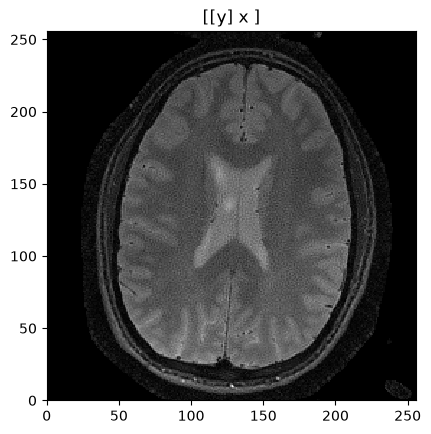

In [33]:
pl.ImagePlot(recon)